# Exploratory analysis — financial complaint triage (CFPB)

Goal: understand the data **before** running Laya/fine-tuning, so the final analysis has
context. Nothing here calls a paid API; the only "model" in this notebook is a classic baseline
(TF-IDF + logistic regression, seconds on CPU) plus a read of the GPT results that already exist.

Questions this notebook answers:
1. How does the real dataset compare with the experiment sample (volume, queues, fraud, template letters)?
2. How much text fits in Laya's token budget — will it decide "without reading" part of the complaint?
3. Is the task separable by vocabulary? Does a cheap classic model already solve it?
4. Where does GPT go wrong, and are its probabilities calibrated (important for the cascade)?
5. What this implies for the experiment design and for the post.

In [1]:
import json, os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer
from laya.common import build_sequence
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from common import PRODUCTS, QUESTIONS, MAX_CHARS, map_product, fraud_label
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_colwidth", 120)

# reference palette (dataviz skill): blue = main series, orange = comparison
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": .6,
                     "axes.axisbelow": True, "font.size": 9})
QUEUES = list(PRODUCTS)

test = pd.read_parquet("data/test.parquet")
train = pd.read_parquet("data/train.parquet")
raw = pd.read_parquet("data/cfpb_2023plus.parquet")
print(f"raw 2023+ with narrative: {len(raw):,} | train {len(train):,} | test {len(test):,}")

raw 2023+ with narrative: 533,397 | train 3,600 | test 1,800


## 1. Real dataset vs. sample — and the template-letter problem

In [2]:
raw["queue"] = [map_product(p, s) for p, s in zip(raw["product"], raw["sub_product"])]
raw["fraud"] = [fraud_label(i, s) for i, s in zip(raw["issue"], raw["sub_issue"])]
txt = raw["consumer_complaint_narrative"]
key = txt.str.lower().map(lambda t: re.sub(r"[^a-z]+", " ", t)[:300])
raw["template_dup"] = key.duplicated(keep=False)

print(f"texts that are a (near-)exact copy of another: {raw.template_dup.mean():.1%}")
print(f"  in credit_reporting: {raw.loc[raw['queue']=='credit_reporting','template_dup'].mean():.1%}")
print(f"  in the other queues: {raw.loc[raw['queue']!='credit_reporting','template_dup'].mean():.1%}")
top = key[raw.template_dup].value_counts().head(5)
print("\nMost repeated openings (credit repair letters):")
for k, n in top.items():
    print(f"  {n:>6,}x  {k[:110]}...")

texts that are a (near-)exact copy of another: 58.7%
  in credit_reporting: 71.5%
  in the other queues: 13.1%

Most repeated openings (credit repair letters):
   7,634x  in accordance with the fair credit reporting act the list of accounts below has violated my federally protecte...
   4,111x  i m really not sure what happened i have mailed off letters to the credit bureaus continuously and thus far i ...
   4,000x  my name is xxxx xxxx this complaint is not made in error neither is it being made by a third party i declare u...
   3,951x  i m really not sure what happened i have mailed off letters to the credit bureaus continuously and thus far i ...
   3,575x  my name is xxxx xxxx xxxx this complaint is not made in error neither is it being made by a third party i decl...


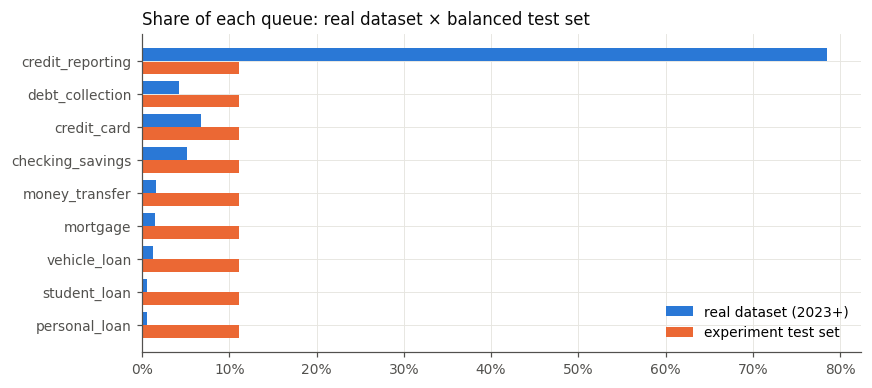

,real dataset (2023+),experiment test set
queue,,
credit_reporting,78.5%,11.1%
debt_collection,4.2%,11.1%
credit_card,6.7%,11.1%
checking_savings,5.1%,11.1%
money_transfer,1.6%,11.1%
mortgage,1.5%,11.1%
vehicle_loan,1.3%,11.1%
student_loan,0.5%,11.1%
personal_loan,0.6%,11.1%


In [3]:
real = raw.dropna(subset=["queue"])
dist = pd.DataFrame({"real dataset (2023+)": real["queue"].value_counts(normalize=True),
                     "experiment test set": test["queue"].value_counts(normalize=True)}).loc[QUEUES]
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(QUEUES))
ax.barh(y - .2, dist.iloc[:, 0], .38, color=BLUE, label=dist.columns[0])
ax.barh(y + .2, dist.iloc[:, 1], .38, color=ORANGE, label=dist.columns[1])
ax.set_yticks(y, QUEUES); ax.invert_yaxis(); ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Share of each queue: real dataset × balanced test set", loc="left", color=INK)
ax.legend(frameon=False, loc="lower right"); plt.tight_layout(); plt.show()
dist.style.format("{:.1%}")

**Reading:** in the real dataset, *credit_reporting* dominates and a good part of it is repeated template letters.
The test set is balanced (200 per queue) on purpose — otherwise "getting the queue right" would turn into "guessing
credit_reporting". When projecting production cost, the real volume matters (section 7).

In [4]:
fr = pd.DataFrame({
    "fraud in real dataset": real.dropna(subset=["fraud"]).groupby("queue")["fraud"].mean(),
    "fraud in test set": test.groupby("queue")["fraud"].mean(),
    "positives in test set": test.groupby("queue")["fraud"].sum()}).loc[QUEUES]
fr.style.format({"fraud in real dataset": "{:.1%}", "fraud in test set": "{:.1%}", "positives in test set": "{:.0f}"})

,fraud in real dataset,fraud in test set,positives in test set
queue,,,
credit_reporting,0.1%,30.0%,60
debt_collection,14.7%,30.0%,60
credit_card,2.8%,30.0%,60
checking_savings,2.5%,30.0%,60
money_transfer,42.0%,30.0%,60
mortgage,0.0%,0.0%,0
vehicle_loan,4.3%,30.0%,60
student_loan,0.8%,11.0%,22
personal_loan,0.0%,0.0%,0


**Reading:** fraud is concentrated in *money_transfer* (payment-app scams) and
*debt_collection* (debt created by identity theft). *mortgage* and *personal_loan* have
no positives — in those queues the fraud question can only err on the false-positive side.

## 2. Text length × Laya's token budget

In [5]:
mdir = snapshot_download("convaiinnovations/laya", allow_patterns=["tokenizer/*", "rl_agent_config.json"])
cfg = json.load(open(os.path.join(mdir, "rl_agent_config.json")))
tok = AutoTokenizer.from_pretrained(os.path.join(mdir, "tokenizer"))
print("max_len", cfg["max_len"], "| head_max_len", cfg["head_max_len"])

def budget(text, qid):
    q = QUESTIONS[qid]
    iq = {"t": q["type"], "ins": q["instructions"], "crit": q["criteria"]}
    _, _, st = build_sequence(tok, text, iq, cfg["max_len"], cfg["head_max_len"], return_truncation_stats=True)
    return st

rows = []
for t in test.text:
    full = len(tok(t, add_special_tokens=False)["input_ids"])
    cut = t[:MAX_CHARS]
    p, f = budget(cut, "product"), budget(cut, "fraud")
    rows.append({"chars": len(t), "tokens_full": full, "tokens_1500c": p["state_tokens"],
                 "used_product": p["state_tokens_used"], "used_fraud": f["state_tokens_used"]})
tb = pd.DataFrame(rows)
tb["share_seen_product"] = tb.used_product / tb.tokens_full
tb.describe(percentiles=[.25, .5, .75, .9]).round(1)

max_len 512 | head_max_len 192


,chars,tokens_full,tokens_1500c,used_product,used_fraud,share_seen_product
count,1800.0,1800.0,1800.0,1800.0,1800.0,1800.0
mean,1244.4,281.0,201.6,197.7,201.5,0.9
std,1440.8,324.8,113.4,107.4,113.0,0.2
min,101.0,17.0,17.0,17.0,17.0,0.1
25%,427.0,98.8,98.8,98.8,98.8,1.0
50%,851.0,190.5,190.5,190.5,190.5,1.0
75%,1509.2,338.2,314.0,314.0,314.0,1.0
90%,2625.3,586.1,349.0,338.0,349.0,1.0
max,19190.0,4560.0,607.0,338.0,468.0,1.0


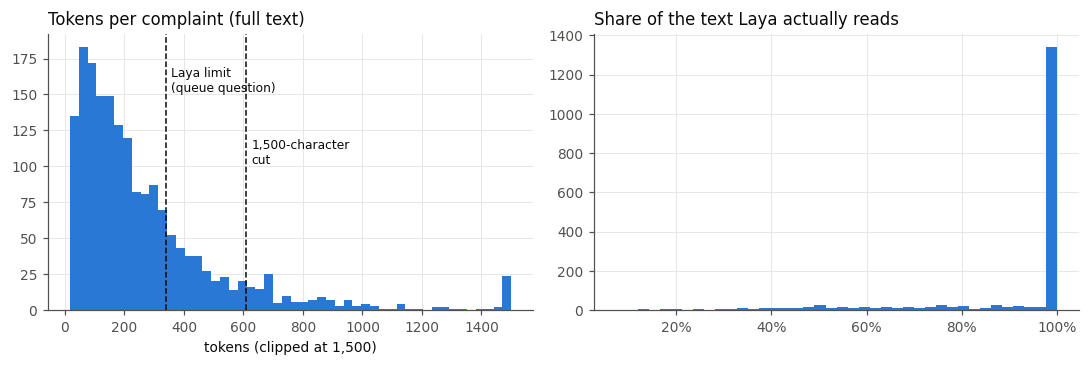

Laya reads the whole text in 73.6% of complaints
Laya reads less than half in 7.8%
State tokens available — queue: 338 | fraud: 468


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(tb.tokens_full.clip(upper=1500), bins=50, color=BLUE)
for x, lab, h in [(tb.used_product.max(), "Laya limit\n(queue question)", .88), (tb.tokens_1500c.max(), "1,500-character\ncut", .62)]:
    axes[0].axvline(x, color=INK, lw=1, ls="--"); axes[0].text(x + 20, axes[0].get_ylim()[1] * h, lab, color=INK, fontsize=8, va="top")
axes[0].set_title("Tokens per complaint (full text)", loc="left", color=INK); axes[0].set_xlabel("tokens (clipped at 1,500)")
axes[1].hist(tb.share_seen_product.clip(upper=1), bins=40, color=BLUE)
axes[1].set_title("Share of the text Laya actually reads", loc="left", color=INK)
axes[1].xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.tight_layout(); plt.show()
print(f"Laya reads the whole text in {(tb.share_seen_product >= .999).mean():.1%} of complaints")
print(f"Laya reads less than half in {(tb.share_seen_product < .5).mean():.1%}")
print(f"State tokens available — queue: {tb.used_product.max()} | fraud: {tb.used_fraud.max()}")

**Reading:** Laya's state budget is short (512 tokens minus the question and the 9 options).
Long complaints are decided by reading only the beginning. This matters for the analysis: if Laya errs
more on long texts, the cause may be the budget, not "intelligence". GPT received the same
1,500 characters, so the comparison is fair on the character cut, but not on the token cut.

## 3. Text quality: redactions and noise

In [7]:
def redaction_share(t):
    words = t.split()
    return sum(bool(re.fullmatch(r"[X/{}$.,()\d]*X{2,}[X/{}$.,()\d]*", w)) for w in words) / max(1, len(words))
test["redacted"] = test.text.map(redaction_share)
print(test.redacted.describe(percentiles=[.5, .9, .99]).round(3))
print("\nShort example per queue:")
for q in QUEUES:
    s = test[test["queue"] == q].sort_values("text", key=lambda s: s.str.len()).iloc[len(test[test["queue"] == q]) // 4]
    print(f"\n[{q}] fraud={s.fraud} | {s.issue} / {s.sub_issue}\n  {s.text[:260]}")

count    1800.000
mean        0.050
std         0.064
min         0.000
50%         0.035
90%         0.108
99%         0.314
max         0.863
Name: redacted, dtype: float64

Short example per queue:

[credit_reporting] fraud=False | Problem with a credit reporting company's investigation into an existing problem / Their investigation did not fix an error on your report
  This is a follow up to # XXXX they results came back as not specified that is un acceptable and it should be delated off my credit report because they did not verify the account just saying not specified when i sent a letter from the court saying they don't re

[debt_collection] fraud=False | Attempts to collect debt not owed / Debt is not yours
  On XXXX of this year I have disputed this account as the car was repoed and I was only the co signer I was never notified that the payments where not being paid until they repoed the car and that was back in 2015 and they refuse to remove it from my credit the

[credit_card

## 4. Is the task separable by vocabulary?

In [8]:
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True,
                      token_pattern=r"(?u)\b[a-wyz][a-z]{2,}\b")  # ignores XXXX
Xtr = vec.fit_transform(train.text.str[:MAX_CHARS]); Xte = vec.transform(test.text.str[:MAX_CHARS])
terms = np.array(vec.get_feature_names_out())

clf_q = LogisticRegression(max_iter=2000, C=5).fit(Xtr, train["queue"])
top_terms = {q: ", ".join(terms[np.argsort(clf_q.coef_[i])[::-1][:10]]) for i, q in enumerate(clf_q.classes_)}
pd.Series(top_terms, name="most indicative terms").to_frame()

,most indicative terms
checking_savings,"account, bank, checking, opened, deposit, overdraft, chase, checking account, funds, the bank"
credit_card,"card, credit card, credit, the card, synchrony, american express, express, limit, capital one, charges"
credit_reporting,"experian, equifax, transunion, reporting, credit, report, credit report, late, bureaus, score"
debt_collection,"debt, collection, the debt, accounts, this debt, owe, owed, midland, collector, report"
money_transfer,"paypal, money, transfer, venmo, funds, wire, bank, the money, transaction, coinbase"
mortgage,"mortgage, escrow, home, cooper, modification, our, the mortgage, loan, property, house"
personal_loan,"affirm, loan, the loan, netcredit, title, personal loan, personal, one main, line credit, line"
student_loan,"nelnet, loans, navient, student, student loan, loan, mae, sallie, plan, repayment"
vehicle_loan,"car, vehicle, auto, acceptance, finance, the car, credit acceptance, the vehicle, loan, car loan"


In [9]:
clf_f = LogisticRegression(max_iter=2000, C=5, class_weight="balanced").fit(Xtr, train["fraud"])
print("terms that most indicate fraud:", ", ".join(terms[np.argsort(clf_f.coef_[0])[::-1][:20]]))

terms that most indicate fraud: opened, fraud, open, identity, name, scammed, fraudulent, scammer, identity theft, theft, credit, scam, stolen, finance charge, bank, down payment, from bank, someone, signature, victim


### Reference baseline: TF-IDF + logistic regression

Not an arm of the post — it is the **floor**. It trains in seconds on CPU with the same 3,600 examples
that Laya's fine-tuning will use. If fine-tuned Laya doesn't beat this, the conclusion changes.

In [10]:
pq = clf_q.predict(Xte); pf = clf_f.predict_proba(Xte)[:, 1]
base = {"product_acc": accuracy_score(test["queue"], pq), "product_f1_macro": f1_score(test["queue"], pq, average="macro"),
        "fraud_f1": f1_score(test.fraud, pf >= .5), "fraud_auc": roc_auc_score(test.fraud, pf)}
pd.Series(base).round(3)

product_acc         0.772
product_f1_macro    0.773
fraud_f1            0.634
fraud_auc           0.865
dtype: float64

## 5. Where GPT goes wrong (already-paid results, read only)

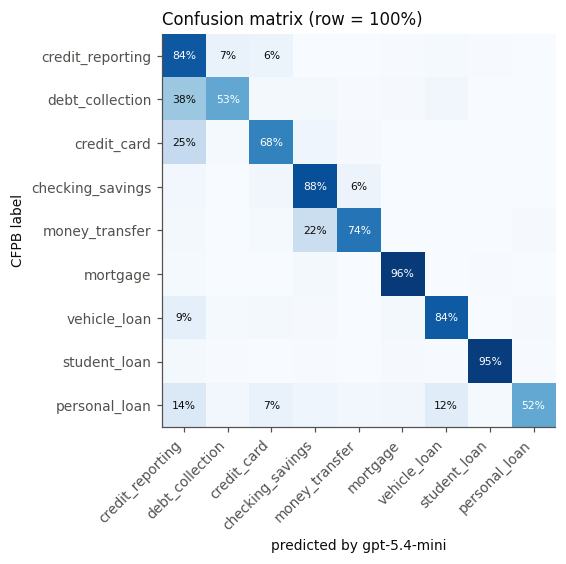

In [11]:
llm = {m: test.merge(pd.read_parquet(f"results/llm_{m}.parquet"), on="id") for m in ["gpt-5.4-nano", "gpt-5.4-mini"]}
mini = llm["gpt-5.4-mini"]
cm = pd.DataFrame(confusion_matrix(mini["queue"], mini.llm_product, labels=QUEUES, normalize="true"), index=QUEUES, columns=QUEUES)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(9), QUEUES, rotation=45, ha="right"); ax.set_yticks(range(9), QUEUES); ax.grid(False)
for i in range(9):
    for j in range(9):
        if cm.iat[i, j] >= .05:
            ax.text(j, i, f"{cm.iat[i, j]:.0%}", ha="center", va="center", fontsize=7, color="white" if cm.iat[i, j] > .5 else INK)
ax.set_xlabel("predicted by gpt-5.4-mini"); ax.set_ylabel("CFPB label")
ax.set_title("Confusion matrix (row = 100%)", loc="left", color=INK); plt.tight_layout(); plt.show()

In [12]:
per_q = pd.DataFrame({m: d.groupby("queue").apply(lambda g: (g["queue"] == g.llm_product).mean()) for m, d in llm.items()})
per_q["tfidf"] = pd.Series(pq == test["queue"].values, index=test.index).groupby(test["queue"]).mean()
per_q.loc[QUEUES].style.format("{:.1%}").background_gradient(cmap="Blues", vmin=.4, vmax=1)

,gpt-5.4-nano,gpt-5.4-mini,tfidf
queue,,,
credit_reporting,85.0%,84.5%,66.5%
debt_collection,54.0%,53.0%,70.0%
credit_card,65.0%,68.0%,73.5%
checking_savings,76.0%,88.0%,76.5%
money_transfer,84.0%,73.5%,78.5%
mortgage,93.5%,96.0%,87.5%
vehicle_loan,58.0%,83.5%,76.5%
student_loan,91.0%,95.0%,91.5%
personal_loan,48.5%,52.5%,74.5%


In [13]:
nano = llm["gpt-5.4-nano"]
both = mini.merge(nano[["id", "llm_product"]], on="id", suffixes=("_mini", "_nano"))
agree = both.llm_product_mini == both.llm_product_nano
print(f"nano and mini agree on {agree.mean():.1%} of complaints")
print(f"  when they agree, they are right {(both.llm_product_mini[agree] == both['queue'][agree]).mean():.1%}")
print(f"  when they disagree, mini is right {(both.llm_product_mini[~agree] == both['queue'][~agree]).mean():.1%}")

mini["len_bucket"] = pd.qcut(mini.text.str.len(), 4, labels=["short", "medium", "long", "very long"])
mini.groupby("len_bucket").apply(lambda g: pd.Series({"queue_acc": (g["queue"] == g.llm_product).mean(),
                                                     "n": len(g), "median_chars": g.text.str.len().median()})).round(3)

nano and mini agree on 82.7% of complaints
  when they agree, they are right 82.3%
  when they disagree, mini is right 52.4%


,queue_acc,n,median_chars
len_bucket,,,
short,0.729,451.0,270.0
medium,0.748,449.0,635.0
long,0.780,450.0,1136.5
very long,0.827,450.0,2287.0


**Reading on the ceiling:** part of the "error" belongs to the label — the consumer picks the product on the form,
and a complaint about debt collection that shows up on the credit report can legitimately
land in either queue. The most-confused pairs above mark that ceiling.

## 6. Is GPT's fraud probability calibrated? (basis for the cascade)

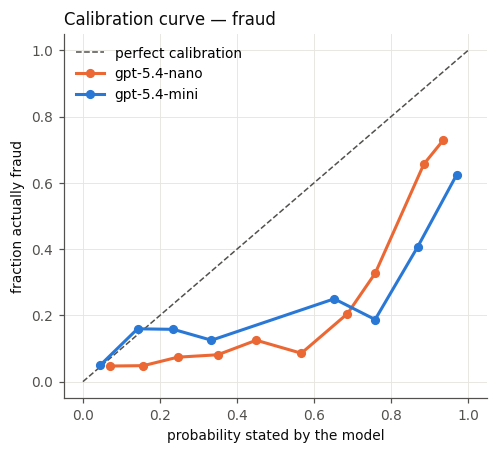

gpt-5.4-nano distinct fraud_probability values: 36 | AUC 0.853
gpt-5.4-mini distinct fraud_probability values: 60 | AUC 0.868


In [14]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="perfect calibration")
for (m, d), c in zip(llm.items(), [ORANGE, BLUE]):
    b = pd.cut(d.llm_fraud_p, np.linspace(0, 1, 11), include_lowest=True)
    r = d.groupby(b).agg(p=("llm_fraud_p", "mean"), y=("fraud", "mean"), n=("fraud", "size")).dropna()
    ax.plot(r.p, r.y, marker="o", ms=5, lw=2, color=c, label=m)
ax.set_xlabel("probability stated by the model"); ax.set_ylabel("fraction actually fraud")
ax.set_title("Calibration curve — fraud", loc="left", color=INK); ax.legend(frameon=False); plt.tight_layout(); plt.show()
for m, d in llm.items():
    print(m, "distinct fraud_probability values:", d.llm_fraud_p.round(2).nunique(), "| AUC", round(roc_auc_score(d.fraud, d.llm_fraud_p), 3))

**Reading:** LLMs "verbalize" round probabilities (0.1 / 0.9) — only a few distinct levels, and
usually poorly calibrated. The Laya/Jev argument is precisely to return a probability trained
with a *proper scoring rule*. If Laya's curve sits closer to the diagonal, that is a concrete
point for the post (reliable confidence threshold = a cascade that works).

## 7. LLM latency and cost — and the projection to real volume

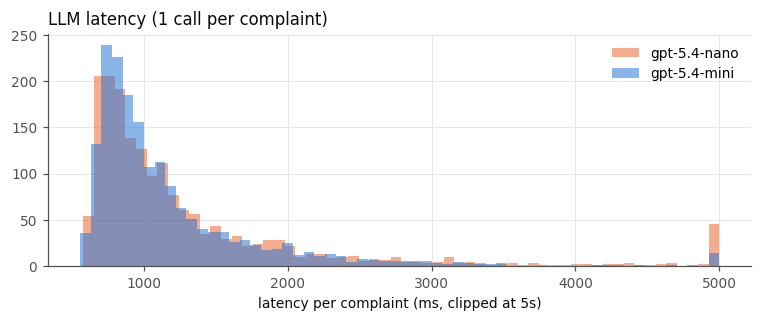

,mean_tokens_in,mean_tokens_out,US$_per_1M_complaints,p50_ms,p95_ms
gpt-5.4-nano,517.6,26.4,136.6,1011.0,3158.2
gpt-5.4-mini,517.6,27.5,511.8,961.2,2403.4


In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
for (m, d), c in zip(llm.items(), [ORANGE, BLUE]):
    ax.hist(d.llm_ms.clip(upper=5000), bins=60, alpha=.55, color=c, label=m)
ax.set_xlabel("latency per complaint (ms, clipped at 5s)"); ax.legend(frameon=False)
ax.set_title("LLM latency (1 call per complaint)", loc="left", color=INK); plt.tight_layout(); plt.show()

cost = pd.DataFrame({m: {"mean_tokens_in": d.tok_in.mean(), "mean_tokens_out": d.tok_out.mean(),
                         "US$_per_1M_complaints": d.cost_usd.mean() * 1e6,
                         "p50_ms": d.llm_ms.median(), "p95_ms": d.llm_ms.quantile(.95)} for m, d in llm.items()}).T
cost.round(1)

In [16]:
# order of magnitude: annual CFPB complaint volume (real dataset, all queues, 2023)
vol_2023 = (raw.date.dt.year == 2023).sum()
print(f"complaints with narrative published in 2023: {vol_2023:,}")
for m in cost.index:
    print(f"  {m}: US$ {cost.loc[m, 'US$_per_1M_complaints'] * vol_2023 / 1e6:,.0f} per year just for triage (2 decisions)")

complaints with narrative published in 2023: 413,724
  gpt-5.4-nano: US$ 57 per year just for triage (2 decisions)
  gpt-5.4-mini: US$ 212 per year just for triage (2 decisions)


## 8. Implications for the experiment and for the post

Numbers from this run (2026-09-29):

1. **Template letters dominate the real dataset.** 58.7% of 2023+ complaints are a (near-)exact copy of
   another — 71.5% in *credit_reporting* (credit repair letters). Without deduplication, any model
   "gets it right" by memorizing templates and the metric is inflated. Already removed from the experiment.

2. **The floor is high: TF-IDF + logistic regression ties with GPT-5.4-mini.** With the same 3,600
   examples Laya will use for fine-tuning, in seconds of CPU: 77.2% on the queue (mini: 77.1%),
   fraud AUC 0.865 (mini: 0.868). The fair comparison for fine-tuned Laya is against *this* floor,
   not only against the zero-shot LLM. This becomes an argument for the post: "before the new architecture,
   the 20-line baseline".

3. **The ceiling is low because of the label.** Errors concentrate in legitimate pairs:
   *debt_collection → credit_reporting* (debt that shows up on the report), *credit_card →
   credit_reporting*, *money_transfer → checking_savings*. Queues with their own vocabulary
   (*mortgage*, *student_loan*) exceed 95%. The possible gain lies in ~4 queues.

4. **Laya's token budget is real, but not dominant.** It reads the whole text in 73.6% of
   complaints; less than half in 7.8%. However, GPT is *more* accurate on long texts (83% vs 73%
   on short ones) — exactly where Laya truncates. Analyze Laya by length bucket.

5. **GPT is overconfident on fraud.** When it states ~0.9, the actual fraud fraction is ~0.6–0.7;
   when it states ~0.6, it is ~0.2. An LLM's probability can't serve as a cascade threshold without
   recalibration. This is where Laya (trained with a *proper scoring rule* + temperature) can win
   demonstrably — and it is the most "senior" point of the post.

6. **nano × mini agreement is a cheap confidence signal:** they agree on 82.7% and, when
   they agree, are right 82.3%; when they disagree, mini is right 52.4%.

7. **At CFPB scale, cost is not the argument.** Triaging ~414 thousand complaints/year would cost
   US$ 57 (nano) to US$ 212 (mini). The cost argument only shows up at volumes of millions per day
   (transactions, app messages, fraud events). For *complaints*, the strong arguments are
   **latency** (~1 s p50 and 2.4–3.2 s p95 for the LLM vs. tens of ms), **calibration** and **data that
   never leaves the premises** (regulated: LGPD, banking secrecy). The post should say this explicitly — and
   project cost for a high-volume scenario instead of selling savings where they are irrelevant.